In [1]:
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel, LSTMModel, DecoupledGCNModel, GATv2LSTMModel

epiconfig= EpiConfig(
        disease             = 'influenza',
        level               = 'nuts2',

        horizon_leadtime    = 3,
        sequence_length     = 4,

        feature_popsize     = False,      
        feature_popdens     = True,
        # feature_gisd        = True,
        # feature_popage      = True,
        # feature_kreise_classes= True,
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [2]:
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 250
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.75, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph1').build()
graphloader2        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph2').build()
graphloader3        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph3').build()
graphloader4        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph4').build()
graphloader5        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph5').build()
graphloader6        = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph6').build()
graphloader10       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph10').build()
graphloader13       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph13').build()
graphloader16       = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph16').build()


==                     gcn2                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(38, 4, 4), y=(38, 1), edge_index=(2, 174), edge_weight=(174,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8530   |   1.3244   |    v     |           |
|  002  |   0.8123   |   0.9586   |    v     |           |
|  003  |   0.7316   |   0.8546   |    v     |           |
|  004  |   0.7100   |   0.7605   |    v     |           |
|  005  |   0.6894   |   0.9149   |          |   1/20    |
|  006  |   0.6842   |   0.7053   |    v     |           |
|  007  |   0.6371   |   0.7843   |          |   1/20    |
|  008  |   0.6265   |   0.7002   |    v     |           |
|  009  |   0.5895   |   0.7890   |          |   1/20    |
|  010  |   0.6363   |   0.6799   |    v     |           |
|  011  |   0.5763   |   0.6807   |          |   1/20    |
|  012  |   0.5853   |   0.6802   |        

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:336: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5653
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 589.77it/s]

Test loss: 0.5250
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

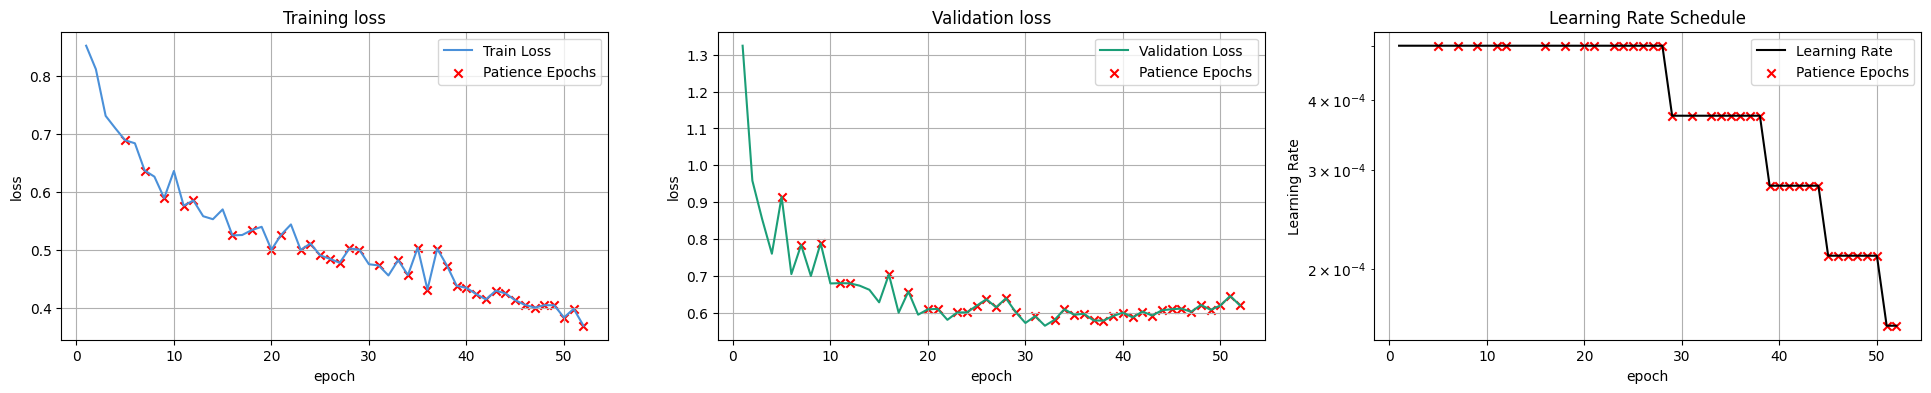

In [3]:
from src.models import GCN2Model

# identity graph. self loops will be False
gcn2 = GCN2Model(graphloader2, name = 'gcn2', verbose = 2)
gcn2.set_model_hparams(dropout = 0.3, self_loops=False)
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
gcn2.show_forecasts(26)


==                     gat2                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(38, 4, 4), y=(38, 1), edge_index=(2, 174), edge_weight=(174,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.0333   |   2.4125   |    v     |           |
|  002  |   0.9129   |   1.5723   |    v     |           |
|  003  |   0.6928   |   0.8796   |    v     |           |
|  004  |   0.7178   |   1.0776   |          |   1/20    |
|  005  |   0.6531   |   0.9219   |          |   2/20    |
|  006  |   0.6338   |   1.0756   |          |   3/20    |
|  007  |   0.5872   |   0.8396   |    v     |           |
|  008  |   0.5696   |   0.8687   |          |   1/20    |
|  009  |   0.5655   |   0.7927   |    v     |           |
|  010  |   0.5517   |   0.7730   |    v     |           |
|  011  |   0.5444   |   0.7616   |    v     |           |
|  012  |   0.5254   |   0.6863   |    v   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:336: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.5038
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 288.58it/s]


Test loss: 0.5919
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

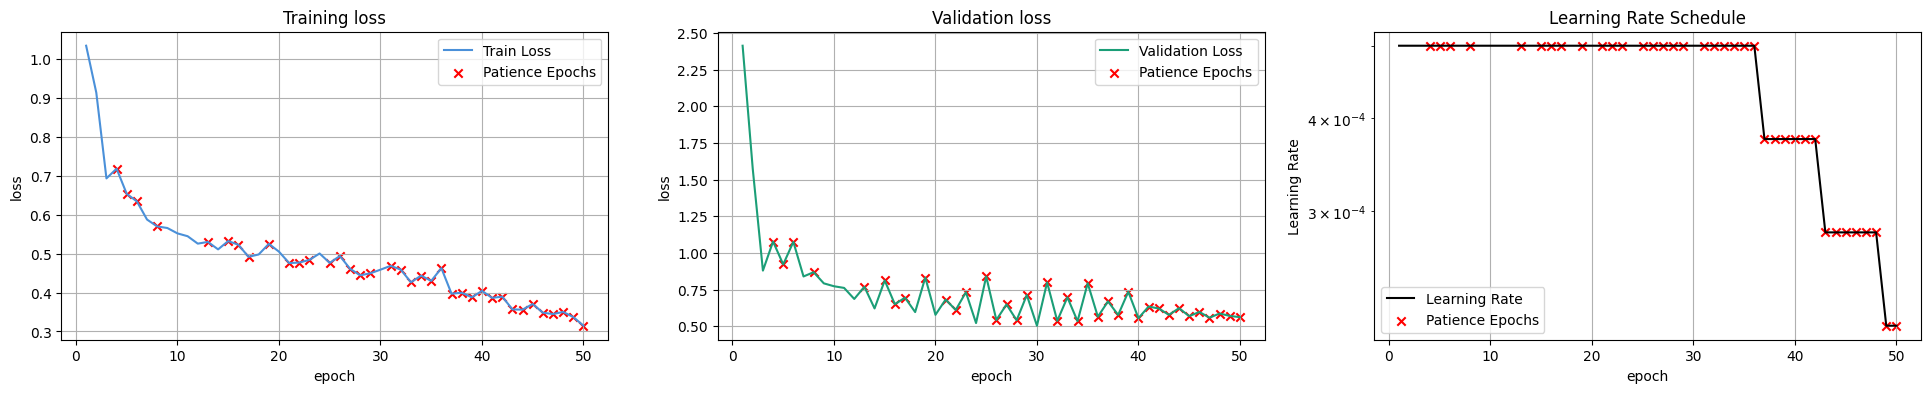

In [4]:

# identity graph. self loops will be False
gat2 = GATv2LSTMModel(graphloader2, name = 'gat2', verbose = 2)
gat2.set_model_hparams(dropout = 0.3, self_loops=False)
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26)


==                     gcn1                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(38, 4, 4), y=(38, 1), edge_index=(2, 38), edge_weight=(38,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8846   |   1.3355   |    v     |           |
|  002  |   0.7585   |   1.0078   |    v     |           |
|  003  |   0.7038   |   0.8139   |    v     |           |
|  004  |   0.6780   |   0.7898   |    v     |           |
|  005  |   0.6212   |   0.7683   |    v     |           |
|  006  |   0.6171   |   0.7110   |    v     |           |
|  007  |   0.6116   |   0.6624   |    v     |           |
|  008  |   0.5900   |   0.7012   |          |   1/20    |
|  009  |   0.5768   |   0.6301   |    v     |           |
|  010  |   0.5623   |   0.5963   |    v     |           |
|  011  |   0.5461   |   0.6089   |          |   1/20    |
|  012  |   0.5519   |   0.5860   |    v     

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:336: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.4715
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 614.11it/s]

Test loss: 0.5285
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

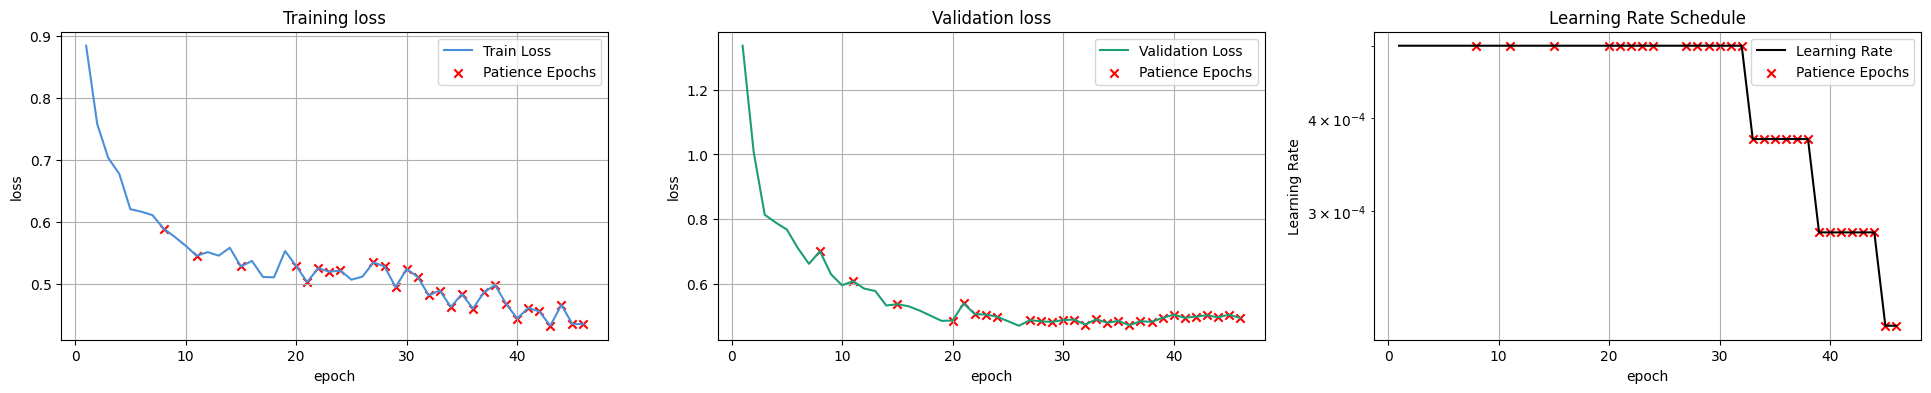

In [5]:
gcn1 = GCN2Model(graphloader1, name = 'gcn1', verbose = 2)
gcn1.set_model_hparams(dropout = 0.3, self_loops=False)
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26)

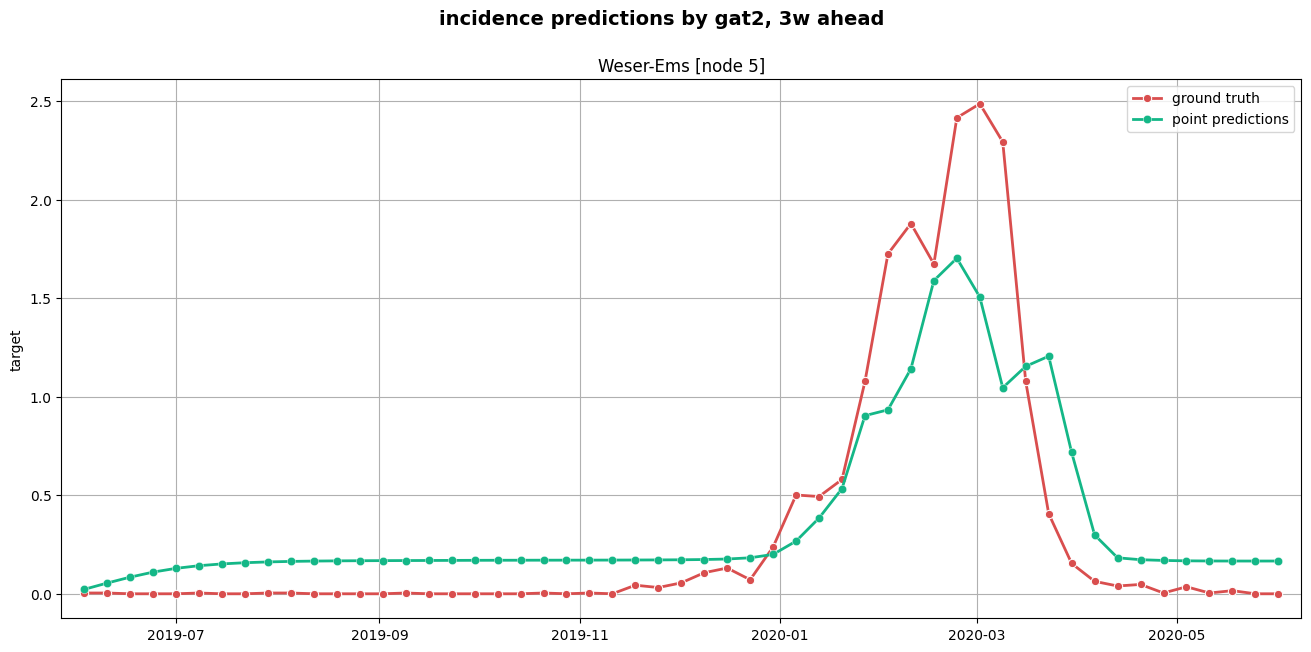

In [26]:
gat2.show_forecasts(5).show()

In [7]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()


baseline_models = [persistence, climateology]

In [8]:
gcn_models = [gcn1,gcn2,gat2]

models = baseline_models + gcn_models

model_evaluation = Evaluator(models).add_evaluation()

computing metrics nodewise:   0%|                                                                                                                                                     | 0/190 [00:00<?, ?it/s]

computing metrics nodewise: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:00<00:00, 637.23it/s]


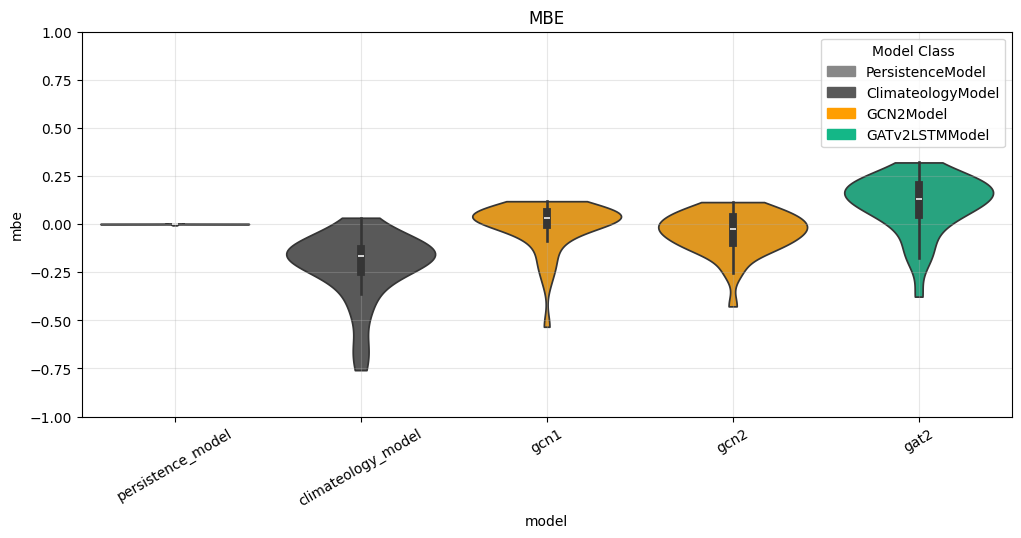

In [18]:
model_evaluation.plotter.plot_metric(0,'test','mbe','violin', vmin = -1, vmax = 1).show()

In [10]:
gcn1.save_model('experiment_2')

✓ Model saved: Wissdaten/ZKI-PH4/deschrijvers_wissdaten/project_utilities/infectious_disease_gnn/models/experiment_2/gcn1.pt


In [11]:
# minimal load — supply dataloader
graph_dlm = GraphDataLoaderManager(data_orch).retrieve_static_graph('graph1').build()
model = GCN2Model(graph_dlm).load('gcn1', 
                                   subdir='experiment_2',
                                   dataloadermanager=graph_dlm)


✓ Model loaded: gcn1.pt
